# CEMVI: Fictional support-arm vibration

## Question

How does changing the material of the fictional support arm affect its movement when the same imaginary fan-and-motor module gives it a repeated push?

## What the model represents

A fictional fan-and-motor module sits at the free end of the support arm shown in the material-support notebook. The model follows only the small up-and-down movement of that end, measured from its resting position. The arm acts like a spring, and a damper represents resistance that gradually reduces movement.

| Part of the model | Symbol | Meaning | Value |
|---|---|---|---|
| Moving module mass | m | How much mass we assume moves up and down | 10 kg, invented; the same for both arms |
| Arm stiffness | k | How strongly the arm resists bending | Steel: approximately 92,593 N/m; aluminium: approximately 31,944 N/m, calculated in the material-support notebook |
| Damping | c | Resistance to movement | Calculated for each arm from the invented damping ratio 0.10 |
| Repeated push | F(t) | The imaginary force that changes with time | Invented 10 Hz frequency and peak amplitude up to 5 N |
| Movement | x(t) | How far the arm's end moves from its resting position | Calculated by this model |

## Model equation

$$m\ddot{x}+c\dot{x}+kx=F(t)$$

In simple words: the moving mass, the resistance to motion, and the arm's springiness together determine how the arm responds to the repeated push.

The push is represented as $F(t)=F_0\cos(2\pi f t)$. Here, $F_0$ is the size of the push and $f$ is how many pushes occur each second. The invented inputs below set the peak amplitude to 5 N and frequency to 10 Hz.

## Boundary

This is an invented educational example, not a measurement of a real fan, motor, chiller, or refinery. The 100 N force in the material-support notebook is a separate static example; it is not the repeated force in this vibration model. The mass of the arm itself is left out of this simple moving-mass model. Hourly cooling demand cannot tell us a machine's vibration frequency. An invented rule links hourly cooling load to repeated-force amplitude; its form is stated in the numerical inputs below.

## Numerical inputs

| Input | Symbol | Invented value or source |
|---|---|---|
| Moving fan-and-motor module mass | m | 10 kg, invented; the same for both arms |
| Damping ratio | ζ | 0.10, invented; the same for both arms |
| Repeated-push frequency | f | 10 Hz, invented (10 pushes each second) |
| Largest repeated-push amplitude | F₀,peak | 5 N, invented |
| Largest hourly cooling load | Qpeak | 33 kW, from our fictional cooling-demand table |
| Steel arm stiffness | k | 92,592.59 N/m, calculated earlier on |
| Aluminium arm stiffness | k | 31,944.44 N/m, calculated earlier on |

For each hour, I assume the size of the repeated push changes with the fictional cooling load:

$$F_{0,h}=5\frac{Q_h}{33}\ \mathrm{N}$$

Here, Q_h is that hour's cooling load in kW. Within each hour, the imaginary push repeats at 10 Hz:

$$F_h(t)=F_{0,h}\cos(2\pi(10)t)$$

The hourly cooling load sets the *assumed size* of the push; t measures seconds within the hour. This link is invented for comparison. Cooling demand by itself cannot tell us a real fan's vibration force or frequency.

The model's natural frequency is $f_n=\sqrt{k/m}/(2\pi)$. Damping is calculated separately for each arm using $c=2\zeta\sqrt{km}$. These equations come from the mass–spring–damper model recorded in `sources.md/vibration_model.md`.

In [1]:
from pathlib import Path
import csv
import math

# Find the existing cooling-demand file.
possible_paths = [
    Path("../data/cooling_demand.csv"),
    Path("data/cooling_demand.csv"),
]
csv_path = next((p for p in possible_paths if p.is_file()), None)

if csv_path is None:
    raise FileNotFoundError("Could not find data/cooling_demand.csv")

with csv_path.open(newline="", encoding="utf-8-sig") as file:
    rows = list(csv.DictReader(file))

hours = [row["hour"] for row in rows]
cooling_load_kw = [float(row["total_kw"]) for row in rows]

if len(rows) != 24:
    raise ValueError("Expected 24 hourly cooling-load rows.")

# Invented inputs
mass_kg = 10.0
damping_ratio = 0.10
push_frequency_hz = 10.0
peak_push_n = 5.0

# Tip stiffness calculated earlier on
stiffness_n_per_m = {
    "Steel": 92592.59,
    "Aluminium": 31944.44,
}

peak_load_kw = max(cooling_load_kw)
push_amplitude_n = [
    peak_push_n * load / peak_load_kw
    for load in cooling_load_kw
]

print(f"Hours loaded: {len(hours)}")
print(f"Peak cooling load: {peak_load_kw:.0f} kW")
print(f"Imaginary push frequency: {push_frequency_hz:.0f} Hz")

for material, stiffness in stiffness_n_per_m.items():
    natural_hz = math.sqrt(stiffness / mass_kg) / (2 * math.pi)
    damping_n_s_per_m = 2 * damping_ratio * math.sqrt(
        stiffness * mass_kg
    )
    print(
        f"{material}: natural frequency = {natural_hz:.2f} Hz; "
        f"damping = {damping_n_s_per_m:.2f} N·s/m"
    )

for chosen_hour in ["00:00", "12:00"]:
    index = hours.index(chosen_hour)
    print(
        f"{chosen_hour}: cooling load = {cooling_load_kw[index]:.0f} kW; "
        f"imaginary push amplitude = {push_amplitude_n[index]:.2f} N"
    )

Hours loaded: 24
Peak cooling load: 33 kW
Imaginary push frequency: 10 Hz
Steel: natural frequency = 15.31 Hz; damping = 192.45 N·s/m
Aluminium: natural frequency = 9.00 Hz; damping = 113.04 N·s/m
00:00: cooling load = 15 kW; imaginary push amplitude = 2.27 N
12:00: cooling load = 33 kW; imaginary push amplitude = 5.00 N


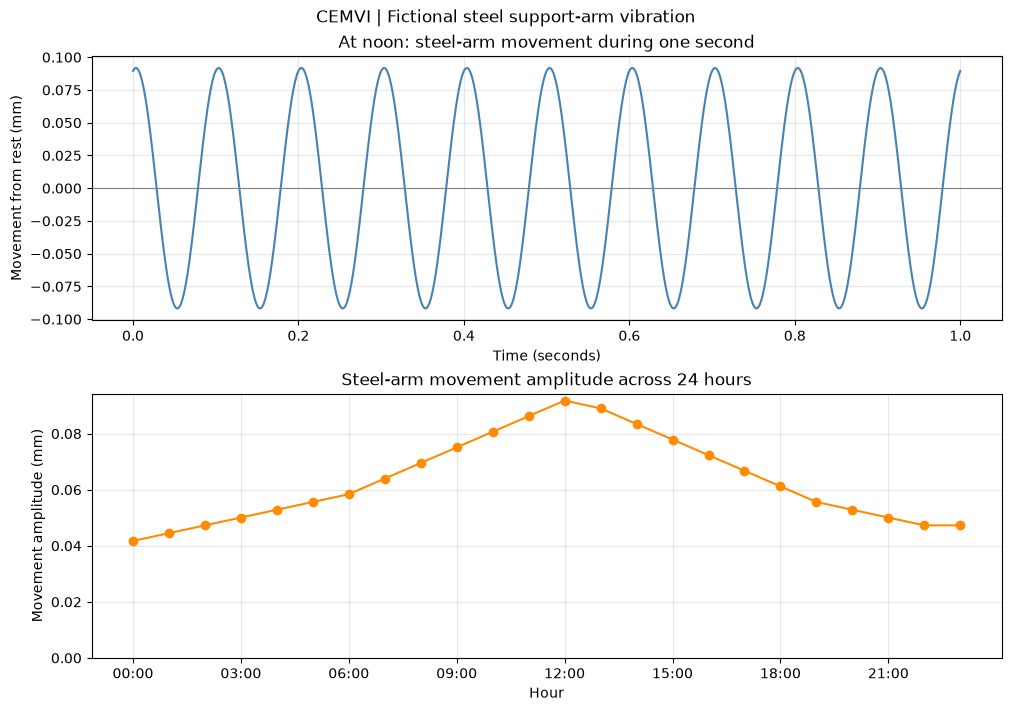

Graph saved: ..\figures\08_vibration_response.png
00:00 movement amplitude: 0.042 mm
12:00 movement amplitude: 0.092 mm


In [2]:
from pathlib import Path
import csv
import math
import matplotlib.pyplot as plt

# Load the existing fictional cooling demands.
possible_paths = [
    Path("../data/cooling_demand.csv"),
    Path("data/cooling_demand.csv"),
]
csv_path = next((p for p in possible_paths if p.is_file()), None)

if csv_path is None:
    raise FileNotFoundError("Could not find data/cooling_demand.csv")

with csv_path.open(newline="", encoding="utf-8-sig") as file:
    rows = list(csv.DictReader(file))

hours = [row["hour"] for row in rows]
cooling_load_kw = [float(row["total_kw"]) for row in rows]

if len(rows) != 24:
    raise ValueError("Expected 24 hourly rows.")

# The same invented inputs chosen earlier on.
mass_kg = 10.0
damping_ratio = 0.10
frequency_hz = 10.0
peak_force_n = 5.0
steel_stiffness_n_per_m = 92592.59

# Calculate the steel arm's damping and response.
omega = 2 * math.pi * frequency_hz
damping_n_s_per_m = (
    2 * damping_ratio
    * math.sqrt(steel_stiffness_n_per_m * mass_kg)
)

response_denominator = math.hypot(
    steel_stiffness_n_per_m - mass_kg * omega**2,
    damping_n_s_per_m * omega,
)

peak_load_kw = max(cooling_load_kw)
force_amplitude_n = [
    peak_force_n * load / peak_load_kw
    for load in cooling_load_kw
]

# Movement amplitude for each hour, converted from metres to millimetres.
amplitude_mm = [
    force / response_denominator * 1000
    for force in force_amplitude_n
]

# Show the quick up-and-down movement during one second at noon.
noon_index = hours.index("12:00")
phase_radians = math.atan2(
    damping_n_s_per_m * omega,
    steel_stiffness_n_per_m - mass_kg * omega**2,
)
time_seconds = [i / 1000 for i in range(1001)]
noon_movement_mm = [
    amplitude_mm[noon_index] * math.cos(omega * t - phase_radians)
    for t in time_seconds
]

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(10, 7), constrained_layout=True
)

ax1.plot(time_seconds, noon_movement_mm, color="steelblue")
ax1.axhline(0, color="gray", linewidth=0.8)
ax1.set_title("At noon: steel-arm movement during one second")
ax1.set_xlabel("Time (seconds)")
ax1.set_ylabel("Movement from rest (mm)")
ax1.grid(alpha=0.3)

ax2.plot(hours, amplitude_mm, marker="o", color="darkorange")
ax2.set_title("Steel-arm movement amplitude across 24 hours")
ax2.set_xlabel("Hour")
ax2.set_ylabel("Movement amplitude (mm)")
ax2.set_xticks(hours[::3])
ax2.set_ylim(bottom=0)
ax2.grid(alpha=0.3)

fig.suptitle("CEMVI | Fictional steel support-arm vibration")

# Save beside your other project figures.
figure_path = (
    csv_path.parent.parent
    / "figures"
    / "08_vibration_response.png"
)
figure_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(figure_path, dpi=150)
plt.show()

print(f"Graph saved: {figure_path}")
print(f"00:00 movement amplitude: {amplitude_mm[hours.index('00:00')]:.3f} mm")
print(f"12:00 movement amplitude: {amplitude_mm[noon_index]:.3f} mm")

## Amplitude Graph observation

For the fictional steel arm, the calculated movement amplitude is about 0.042 mm at 00:00 and 0.092 mm at 12:00. The upper graph shows rapid movement at noon; the lower graph shows how its calculated amplitude changes from hour to hour.

The daily graph follows my invented rule that a larger cooling load produces a larger repeated-push amplitude. It is not measured vibration. The calculation shows steady movement after any start-up effects have faded. I will compare the aluminium arm using the same inputs next.

Steel: natural frequency = 15.31 Hz; 12:00 movement amplitude = 0.092 mm
Aluminium: natural frequency = 9.00 Hz; 12:00 movement amplitude = 0.483 mm


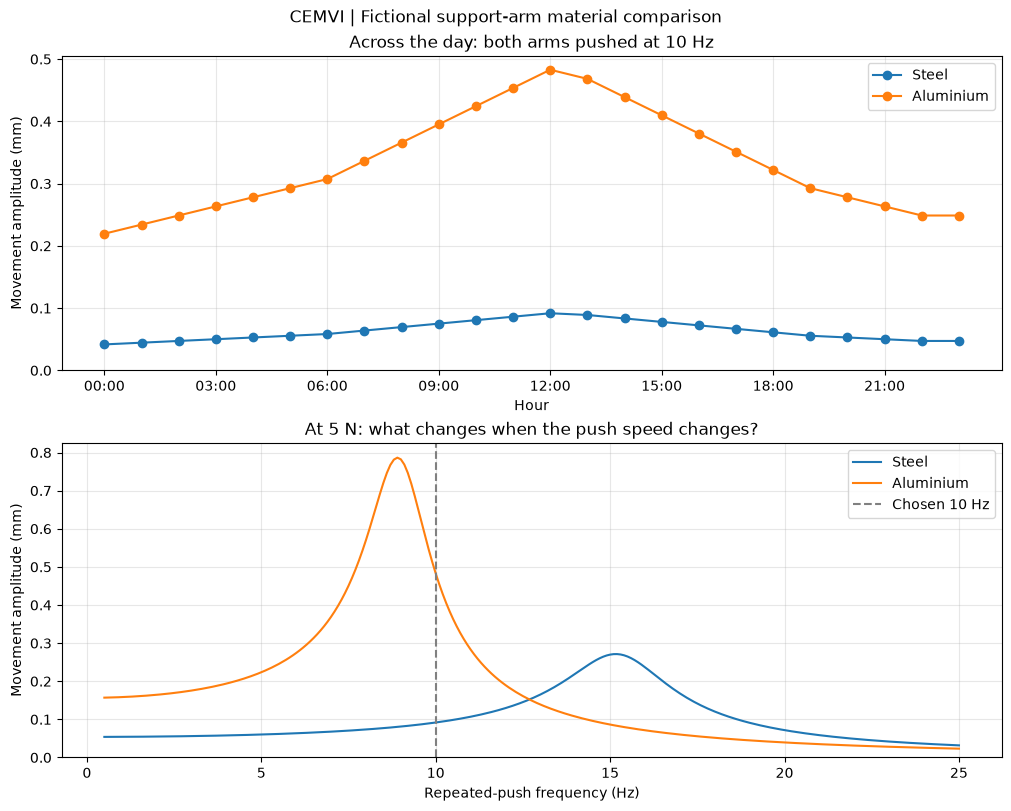

Graph saved: ..\figures\09_material_vibration_comparison.png


In [3]:
from pathlib import Path
import csv
import math
import matplotlib.pyplot as plt

# Load the existing fictional cooling demands.
possible_paths = [
    Path("../data/cooling_demand.csv"),
    Path("data/cooling_demand.csv"),
]
csv_path = next((p for p in possible_paths if p.is_file()), None)

if csv_path is None:
    raise FileNotFoundError("Could not find data/cooling_demand.csv")

with csv_path.open(newline="", encoding="utf-8-sig") as file:
    rows = list(csv.DictReader(file))

hours = [row["hour"] for row in rows]
cooling_load_kw = [float(row["total_kw"]) for row in rows]

if len(rows) != 24 or "12:00" not in hours:
    raise ValueError("Expected 24 rows including 12:00.")

# The invented inputs: identical for both arms.
mass_kg = 10.0
damping_ratio = 0.10
chosen_frequency_hz = 10.0
peak_force_n = 5.0

# Stiffness values calculated earlier on.
materials = {
    "Steel": 92592.59,
    "Aluminium": 31944.44,
}

force_by_hour_n = [
    peak_force_n * load / max(cooling_load_kw)
    for load in cooling_load_kw
]

def movement_amplitude_mm(force_n, stiffness, damping, frequency_hz):
    omega = 2 * math.pi * frequency_hz
    denominator = math.hypot(
        stiffness - mass_kg * omega**2,
        damping * omega,
    )
    return 1000 * force_n / denominator

# The lower graph tests different imaginary push frequencies.
# Its force is held at 5 N for a clear comparison.
test_frequencies_hz = [0.5 + 0.1 * i for i in range(246)]

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(10, 8), constrained_layout=True
)

noon_index = hours.index("12:00")

for material, stiffness in materials.items():
    # The same damping ratio gives each arm its own damping coefficient.
    damping = (
        2 * damping_ratio * math.sqrt(stiffness * mass_kg)
    )
    natural_frequency_hz = (
        math.sqrt(stiffness / mass_kg) / (2 * math.pi)
    )

    hourly_amplitude_mm = [
        movement_amplitude_mm(
            force, stiffness, damping, chosen_frequency_hz
        )
        for force in force_by_hour_n
    ]

    frequency_amplitude_mm = [
        movement_amplitude_mm(
            peak_force_n, stiffness, damping, frequency
        )
        for frequency in test_frequencies_hz
    ]

    ax1.plot(hours, hourly_amplitude_mm, marker="o", label=material)
    ax2.plot(
        test_frequencies_hz, frequency_amplitude_mm,
        label=material
    )

    print(
        f"{material}: natural frequency = "
        f"{natural_frequency_hz:.2f} Hz; "
        f"12:00 movement amplitude = "
        f"{hourly_amplitude_mm[noon_index]:.3f} mm"
    )

ax1.set_title("Across the day: both arms pushed at 10 Hz")
ax1.set_xlabel("Hour")
ax1.set_ylabel("Movement amplitude (mm)")
ax1.set_xticks(hours[::3])
ax1.set_ylim(bottom=0)
ax1.grid(alpha=0.3)
ax1.legend()

ax2.axvline(
    chosen_frequency_hz,
    color="gray",
    linestyle="--",
    label="Chosen 10 Hz",
)
ax2.set_title("At 5 N: what changes when the push speed changes?")
ax2.set_xlabel("Repeated-push frequency (Hz)")
ax2.set_ylabel("Movement amplitude (mm)")
ax2.set_ylim(bottom=0)
ax2.grid(alpha=0.3)
ax2.legend()

fig.suptitle("CEMVI | Fictional support-arm material comparison")

figure_path = (
    csv_path.parent.parent
    / "figures"
    / "09_material_vibration_comparison.png"
)
figure_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(figure_path, dpi=150)
plt.show()

print(f"Graph saved: {figure_path}")

## Frequency Comparison Graph observation

At the invented 10 Hz push frequency and at 12:00, the calculated movement amplitude is approximately 0.092 mm for steel and 0.483 mm for aluminium. Both arms carry the same assumed 10 kg moving mass and receive the same force. Their different stiffness values change their natural frequencies.

The 10 Hz push is close to the aluminium arm's calculated natural frequency of about 9 Hz, which helps explain its larger movement here. The frequency graph shows that the answer depends on the chosen push frequency. These results are conditional on the invented mass, force, damping ratio, and simplified model; they are not measurements or a general judgement that one material is always better.

In [4]:
import math

# The same invented model inputs used.
mass_kg = 10.0
damping_ratio = 0.10
frequency_hz = 10.0
noon_force_n = 5.0
omega = 2 * math.pi * frequency_hz

materials = {
    "Steel": {
        "stiffness": 92592.59,
        "static_mm": 1.080,
    },
    "Aluminium": {
        "stiffness": 31944.44,
        "static_mm": 3.130,
    },
}

# A small time step lets us estimate speed and acceleration
# directly from nearby positions.
time_step_s = 0.0001
sample_times_s = [0.000, 0.013, 0.029, 0.047, 0.083]
natural_frequencies = {}

for material, values in materials.items():
    stiffness = values["stiffness"]
    damping = (
        2 * damping_ratio * math.sqrt(stiffness * mass_kg)
    )
    natural_hz = (
        math.sqrt(stiffness / mass_kg) / (2 * math.pi)
    )
    natural_frequencies[material] = natural_hz

    # Check 1: Does the old 100 N static example still agree?
    static_movement_mm = 100 / stiffness * 1000
    assert abs(
        static_movement_mm - values["static_mm"]
    ) < 0.001, f"{material}: static check failed"

    # Recreate initial calculated noon movement.
    response_denominator = math.hypot(
        stiffness - mass_kg * omega**2,
        damping * omega,
    )
    amplitude_m = noon_force_n / response_denominator
    phase = math.atan2(
        damping * omega,
        stiffness - mass_kg * omega**2,
    )

    def position_m(time_s):
        return amplitude_m * math.cos(omega * time_s - phase)

    # Check 2: Put positions back into m*a + c*v + k*x = F(t).
    errors_n = []

    for time_s in sample_times_s:
        position = position_m(time_s)
        speed = (
            position_m(time_s + time_step_s)
            - position_m(time_s - time_step_s)
        ) / (2 * time_step_s)
        acceleration = (
            position_m(time_s + time_step_s)
            - 2 * position
            + position_m(time_s - time_step_s)
        ) / time_step_s**2

        left_side_n = (
            mass_kg * acceleration
            + damping * speed
            + stiffness * position
        )
        applied_force_n = (
            noon_force_n * math.cos(omega * time_s)
        )
        errors_n.append(abs(left_side_n - applied_force_n))

    largest_error_n = max(errors_n)
    assert largest_error_n < 0.01, (
        f"{material}: motion-equation check failed"
    )

    print(f"{material}:")
    print(f"  static check: {static_movement_mm:.3f} mm — PASS")
    print(f"  Natural frequency: {natural_hz:.2f} Hz")
    print(
        f"  Largest force-balance error: "
        f"{largest_error_n:.6f} N — PASS"
    )

# Check 3: With the same moving mass, the stiffer arm
# should have the higher natural frequency.
assert natural_frequencies["Steel"] > natural_frequencies["Aluminium"]
print("Stiffness and natural-frequency order — PASS")
print("ALL CHECKS PASSED")

Steel:
  static check: 1.080 mm — PASS
  Natural frequency: 15.31 Hz
  Largest force-balance error: 0.000014 N — PASS
Aluminium:
  static check: 3.130 mm — PASS
  Natural frequency: 9.00 Hz
  Largest force-balance error: 0.000065 N — PASS
Stiffness and natural-frequency order — PASS
ALL CHECKS PASSED


## Verification

I checked the vibration model in three ways:

1. Using the static force of 100 N, force ÷ stiffness gives approximately 1.080 mm for steel and 3.130 mm for aluminium. These agree with my earlier bending results.
2. I estimated movement, speed, and acceleration at several times and inserted them into m × acceleration + c × speed + k × movement = applied force. The largest mismatch was below 0.01 N for each arm.
3. With the same assumed moving mass, the stiffer steel arm has the higher calculated natural frequency, as expected.

The units also fit: each term in the motion equation is a force in newtons (N). These checks show that my simplified calculations are internally consistent. They do not verify the invented inputs against a real machine.

## Results and interpretation

| Result | Steel arm | Aluminium arm |
|---|---:|---:|
| Arm mass from earlier on | 1.185 kg | 0.405 kg |
| Calculated tip stiffness | 92,592.59 N/m | 31,944.44 N/m |
| Natural frequency with the assumed 10 kg module | 15.31 Hz | 9.00 Hz |
| Calculated movement amplitude at 12:00 and 10 Hz | 0.092 mm | 0.483 mm |

The aluminium arm has 0.780 kg less arm mass, approximately 65.8% less than the steel arm. Under this particular invented 10 Hz push, however, its calculated movement is larger. One reason is that 10 Hz is close to the aluminium model's natural frequency of about 9 Hz. The frequency comparison graph shows why the result depends on push frequency: I cannot conclude that one material always vibrates less.

The assumed 10 kg moving module is separate from the arm masses in the first row. I used the same module mass and the same damping ratio for both arms to focus the comparison on support stiffness. Their calculated damping coefficients are therefore different.

## Limits of this result

- The room, module, repeated force, 10 Hz frequency, and damping ratio are invented. No equipment vibration was measured.
- I invented the rule that hourly cooling load changes the size of the repeated push. A cooling-load table cannot establish a real machine's vibration.
- The model considers one small up-and-down movement. It omits the arm's distributed moving mass, joints, fasteners, other vibration modes, and start-up behaviour.
- The graphs show calculated steady-state movement. They do not establish whether either support is safe, durable, or suitable for construction.
- The checks test whether the simplified calculations agree with the initial result and the motion equation. They cannot validate the invented inputs against real equipment.

## What this part of CEMVI demonstrates

This educational comparison connects a material choice to arm mass, stiffness, natural frequency, and vibration response. It shows how changing an assumption, especially push frequency, can change the conclusion. The material properties and vibration equations are recorded in the public-source logs; the case inputs are identified as invented.